
# Anomaly-detection model benchmark: CLIP vs VLM on CPU

**Objective.** Determine which of five candidate models — **MobileCLIP2-S2, VadCLIP, SigLIP2-B/16-224, SmolVLM, MiniCPM-V** — is most suitable for detecting this project's public-space anomalies (**smoking, littering, rough sleeping, loitering, unattended items**), running on CPU. Each model is scored head-to-head on the *same* balanced set of frames for:

- **Accuracy & F1** — multi-class accuracy / macro-F1, and binary anomaly-vs-normal precision, recall, F1 and ROC-AUC (plus a per-anomaly breakdown).
- **Inference speed** — latency mean/p50/p95 and active throughput (samples/s), CPU float32.
- **Usability** — memory footprint, load time, abstention/error rate, output type, integration effort.

> **Method constraint.** No screenshots and no direct inspection of image files are used anywhere in this notebook. Every number comes from *programmatic inference* through the existing harness (`scripts/benchmark.py`), and every chart plots a **benchmark metric** (F1, AUC, latency, RSS) — never a dataset image.

## Models under test

| Model | Approach | In this head-to-head? |
|---|---|---|
| MobileCLIP2-S2 | image↔text similarity (OpenCLIP port of Apple S2) | yes — frame-level |
| SigLIP2-B/16-224 | independent sigmoid image/text scores | yes — frame-level |
| SmolVLM-500M | generative VLM, deterministic JSON label | yes — frame-level |
| MiniCPM-V 4.0 | generative VLM (≈4 B), single-image chat | yes — frame-level |
| **VadCLIP** | trained *temporal video* anomaly detector | **documented only** (see final section) |

All four runnable models are **reference-free**: they score a frame against the text definitions in `scripts/anomalies.json`, so no per-class reference images need to be curated.


In [1]:

# ---- Configuration ----------------------------------------------------------
import json, sys, time, shutil, subprocess, hashlib, csv
from pathlib import Path

def find_root():
    here = Path.cwd()
    for cand in [here, *here.parents]:
        if (cand / "scripts" / "benchmark.py").exists():
            return cand
    raise RuntimeError("Could not locate project root (scripts/benchmark.py).")

ROOT = find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# The four frame-level models that run inside the existing benchmark harness.
MODELS = ["mobileclip2-s2", "siglip2-b16-224", "smolvlm-500m", "minicpm-v4"]
VADCLIP = "VadCLIP"  # documented only -- separate temporal pipeline

# Display names + a fixed categorical color per model (dataviz reference palette).
MODEL_LABELS = {
    "mobileclip2-s2": "MobileCLIP2-S2",
    "siglip2-b16-224": "SigLIP2-B/16-224",
    "smolvlm-500m": "SmolVLM-500M",
    "minicpm-v4": "MiniCPM-V 4.0",
    "VadCLIP": "VadCLIP",
}
MODEL_COLORS = {
    "mobileclip2-s2": "#2a78d6",   # blue
    "siglip2-b16-224": "#1baf7a",  # aqua
    "smolvlm-500m": "#eda100",     # yellow
    "minicpm-v4": "#e87ba4",       # magenta
    "VadCLIP": "#eb6834",          # orange (separate pipeline)
}

# Shared head-to-head budget: every model sees the SAME balanced frames.
SEED = 42
LIMIT = 80            # total test frames drawn from the manifest
THREADS = 2           # fair, fixed CPU-thread budget for all models
DUTY_CYCLE = 1.0      # no artificial pacing -> measure raw speed
TIMEOUT_S = 3600      # per-model wall-clock cap (MiniCPM-V is the long pole)

MANIFEST = ROOT / "data" / "anomaly_manifest.csv"
RESULTS = ROOT / "results" / "anomaly_headtohead"
FIGDIR = ROOT / "notebooks" / "anomaly_benchmark_figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

print(f"root      : {ROOT}")
print(f"models    : {', '.join(MODELS)}")
print(f"budget    : {LIMIT} frames, seed={SEED}, {THREADS} threads, duty-cycle={DUTY_CYCLE}, timeout={TIMEOUT_S}s")


root      : /home/g31/projects/test_here/capstone_S25
models    : mobileclip2-s2, siglip2-b16-224, smolvlm-500m, minicpm-v4
budget    : 80 frames, seed=42, 2 threads, duty-cycle=1.0, timeout=3600s



## Environment

Reported programmatically below — CPU/RAM/disk, package versions, and which model checkpoints are already cached locally (so the run works offline). No image files are opened.


In [2]:

# ---- Environment report -----------------------------------------------------
import os, platform, shutil as _sh

cpu = os.cpu_count()
try:
    import psutil
    ram_gb = psutil.virtual_memory().total / 1e9
except Exception:
    ram_gb = None
disk_free_gb = _sh.disk_usage(ROOT).free / 1e9

def pkg(name):
    try:
        m = __import__(name)
        return getattr(m, "__version__", "?")
    except Exception as e:
        return f"unavailable ({type(e).__name__})"

print(f"python     : {platform.python_version()}  ({sys.executable})")
print(f"os         : {platform.platform()}")
print(f"cpu threads: {cpu} logical cores")
if ram_gb: print(f"ram        : {ram_gb:.1f} GB total")
print(f"disk free  : {disk_free_gb:.1f} GB at {ROOT}")
for name in ("torch", "transformers", "open_clip", "timm", "PIL"):
    print(f"{name:12}: {pkg(name)}")

# Which checkpoints are already in the local HF cache (offline-capable)?
hf_cache = Path.home() / ".cache" / "huggingface" / "hub"
cached = sorted(p.name for p in hf_cache.glob("models--*")) if hf_cache.is_dir() else []
print(f"\nHF hub cache entries ({len(cached)}):")
for c in cached: print(f"  {c}")


python     : 3.12.3  (/home/g31/projects/test_here/capstone_S25/.venv/bin/python)
os         : Linux-7.0.0-28-generic-x86_64-with-glibc2.39
cpu threads: 64 logical cores
ram        : 269.6 GB total
disk free  : 102.0 GB at /home/g31/projects/test_here/capstone_S25


torch       : 2.14.1+cpu


/home/g31/projects/test_here/capstone_S25/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


transformers: 4.57.1


open_clip   : 3.3.0
timm        : 1.0.30
PIL         : 12.3.0

HF hub cache entries (4):
  models--HuggingFaceTB--SmolVLM-500M-Instruct
  models--google--siglip2-base-patch16-224
  models--openbmb--MiniCPM-V-4
  models--timm--MobileCLIP2-S2-OpenCLIP



## Data preparation

The repo deliberately does **not** import detection boxes; `scripts/derive_labels.py` is the single place that turns per-box YOLO/COCO annotation files into *image-level* labels. It builds one balanced multi-anomaly manifest (16 frames × 5 classes = 80 rows, all in the `test` split) so every model sees an equal number of each class:

| Class | Source & rule | Caveat |
|---|---|---|
| smoking | ≥1 "Smoking" COCO box (`smoking-video.v1i.coco`) | cleanest track; mixed frames count as positive |
| littering | non-empty YOLO label file (`Littering`, train+test) | `valid` split has no images → excluded |
| rough_sleeping | kaggle `laying_dataset` labelled *only* class 0 ("laying") | small set; mixed/standing frames excluded |
| loitering | every frame of ATMGUARD-Loitering-Tracking | **dataset-level proxy** — temporal behaviour, single-frame stand-in |
| normal | "Not Smoking" frames with no "Smoking" box (clean normals) | person-present negatives |

`unattended_items` has no labels in the repo and is intentionally excluded from accuracy. Cross-class frames act as hard negatives; per-anomaly binary metrics are derived post-hoc by re-slicing the predictions, so no extra model runs are needed.


In [3]:

# ---- Build (or reuse) the balanced multi-anomaly manifest -------------------
from scripts.derive_labels import build_manifest, MANIFEST_CLASSES

def _manifest_counts(path: Path):
    if not path.is_file():
        return None
    counts = {}
    with path.open(newline="", encoding="utf-8") as h:
        for row in csv.DictReader(h):
            counts[row["label"]] = counts.get(row["label"], 0) + 1
    return counts

counts = _manifest_counts(MANIFEST)
if counts and all(counts.get(c, 0) >= 16 for c in MANIFEST_CLASSES):
    print(f"[reuse] {MANIFEST.name} already holds a balanced manifest:")
else:
    summary = build_manifest(MANIFEST, per_class=16, seed=SEED)
    counts = summary["per_class"]
    print(f"[build] wrote {summary['rows']} rows to {MANIFEST}")

for c in MANIFEST_CLASSES:
    print(f"  {c:14} {counts.get(c,0)}")
print(f"  {'total':14} {sum(counts.values())}")


[reuse] anomaly_manifest.csv already holds a balanced manifest:
  smoking        16
  littering      16
  rough_sleeping 16
  loitering      16
  normal         16
  total          80



## Benchmark run

`scripts/benchmark.py` is invoked **once** over all four models on the *same* manifest. It selects the shared sample set a single time (seed 42), so every model scores identical frames, and it runs each model in an isolated worker process — important for MiniCPM-V after the CLIP models. The cell below is **idempotent**: if `results/anomaly_headtohead/comparison.csv` already contains all four models with status `ok` under this exact budget, it reuses those results instead of re-running (the first full run takes ~35 min because MiniCPM-V is the long pole).


In [4]:

# ---- Run the head-to-head benchmark (idempotent) ----------------------------
def _comparison_ok(path: Path, models, seed, limit):
    if not path.is_file():
        return False
    try:
        run = json.loads((path.parent / "run.json").read_text(encoding="utf-8"))
        opts = run.get("options", {})
        if opts.get("seed") != seed or int(opts.get("limit", -1)) != limit:
            return False
        if sorted(opts.get("models", [])) != sorted(models):
            return False
    except Exception:
        pass
    rows = list(csv.DictReader(path.open(newline="", encoding="utf-8")))
    by_model = {r["model"]: r for r in rows}
    return all(m in by_model and by_model[m]["status"] == "ok" for m in models)

if _comparison_ok(RESULTS / "comparison.csv", MODELS, SEED, LIMIT):
    print(f"[reuse] {RESULTS/'comparison.csv'} already has all {len(MODELS)} models ok under this budget.")
else:
    if RESULTS.exists():
        shutil.rmtree(RESULTS)
    cmd = [sys.executable, "-I", str(ROOT / "scripts" / "benchmark.py"),
           "--manifest", str(MANIFEST),
           "--models", *MODELS,
           "--limit", str(LIMIT), "--seed", str(SEED),
           "--threads", str(THREADS), "--duty-cycle", str(DUTY_CYCLE),
           "--timeout-seconds", str(TIMEOUT_S),
           "--offline",
           "--output", str(RESULTS)]
    print("running:", " ".join(cmd))
    proc = subprocess.run(cmd, cwd=str(ROOT))
    if proc.returncode != 0:
        raise RuntimeError(f"benchmark.py exited {proc.returncode}")
print("\nResults written to", RESULTS)


[reuse] /home/g31/projects/test_here/capstone_S25/results/anomaly_headtohead/comparison.csv already has all 4 models ok under this budget.

Results written to /home/g31/projects/test_here/capstone_S25/results/anomaly_headtohead



## Results

Parsed from `comparison.csv` plus each model's `summary.json`. One row per model; the full numeric detail lives in `results/anomaly_headtohead/`.


In [5]:

# ---- Parse results into a tidy table ----------------------------------------
def extract(summary: dict) -> dict:
    met = summary.get("metrics", {}) or {}
    binm = met.get("binary", {}) or {}
    return {
        "status": summary.get("status"),
        "coverage": met.get("prediction_coverage"),
        "acc_incl_fail": met.get("accuracy_including_failures"),
        "macro_f1": met.get("macro_f1"),
        "bin_f1": binm.get("f1"),
        "roc_auc": binm.get("roc_auc"),
        "abstain": summary.get("abstentions"),
        "errors": summary.get("errors"),
        "lat_mean": summary.get("latency_mean_seconds"),
        "lat_p50": summary.get("latency_p50_seconds"),
        "lat_p95": summary.get("latency_p95_seconds"),
        "throughput": summary.get("active_samples_per_second"),
        "rss_mb": summary.get("peak_rss_mb"),
        "load_s": summary.get("load_seconds"),
    }

def load_summary(model: str) -> dict:
    p = RESULTS / model / "summary.json"
    return json.loads(p.read_text(encoding="utf-8")) if p.is_file() else {}

summaries = {m: load_summary(m) for m in MODELS}
table = [{"model": MODEL_LABELS[m], "key": m, **extract(summaries.get(m, {}))} for m in MODELS]

def _fmt(x, spec="{:.3f}"):
    return "n/a" if x is None else spec.format(x)

header = f"{'model':16} {'cov':>5} {'acc*':>6} {'macroF1':>8} {'binF1':>7} {'AUC':>6} {'abs':>4} {'p95s':>6} {'thr/s':>6} {'RSSMB':>7}"
print(header); print("-" * len(header))
for r in table:
    print(f"{r['model']:16} {_fmt(r['coverage']):>5} {_fmt(r['acc_incl_fail']):>6} "
          f"{_fmt(r['macro_f1']):>8} {_fmt(r['bin_f1']):>7} {_fmt(r['roc_auc']):>6} "
          f"{str(r['abstain'] or 0):>4} {_fmt(r['lat_p95']):>6} "
          f"{_fmt(r['throughput'],'{:.2f}'):>6} {_fmt(r['rss_mb'],'{:.0f}'):>7}")
print("\n*acc = accuracy including failures (abstentions/errors count as wrong).")


model              cov   acc*  macroF1   binF1    AUC  abs   p95s  thr/s   RSSMB
--------------------------------------------------------------------------------
MobileCLIP2-S2   1.000  0.188    0.086   0.460  0.459    0  0.141   9.13    1112
SigLIP2-B/16-224 1.000  0.275    0.213   0.827  0.626    0  0.205   5.46    1197
SmolVLM-500M     0.000  0.000      n/a     n/a    n/a   80  3.063   0.34    3047
MiniCPM-V 4.0    1.000  0.375    0.266   0.400    n/a    0 20.839   0.06   18685

*acc = accuracy including failures (abstentions/errors count as wrong).



### Visual comparison

One metric per chart; each model keeps its color across all charts, and values are labeled on the bars. These plot **benchmark metrics only** — no dataset images. A model with no usable score (e.g. a VLM that abstained everywhere) simply has no bar for that metric.


In [6]:

# ---- Charts -----------------------------------------------------------------
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

INK = "#0b0b0b"; MUTED = "#898781"; GRID = "#e1e0d9"; BASE = "#c3c2b7"
plt.rcParams.update({"text.color": INK, "axes.edgecolor": BASE, "axes.labelcolor": INK,
                     "xtick.color": MUTED, "ytick.color": MUTED, "figure.facecolor": "#fcfcfb",
                     "axes.facecolor": "#fcfcfb"})

def bar_chart(title, values, ylabel, log=False, fmt="{:.3f}"):
    # values: list of (model_key, value_or_None). One metric, models on x-axis.
    present = [(k, v) for k, v in values if v is not None]
    labels = [MODEL_LABELS[k] for k, _ in present]
    vals = [v for _, v in present]
    colors = [MODEL_COLORS[k] for k, _ in present]
    fig, ax = plt.subplots(figsize=(max(6, 1.4 * len(present)), 3.6))
    bars = ax.bar(range(len(vals)), vals, color=colors, width=0.62)
    if log:
        ax.set_yscale("log")
    for rect, v in zip(bars, vals):
        ax.annotate(fmt.format(v), (rect.get_x() + rect.get_width()/2, v),
                    ha="center", va="bottom", fontsize=9, color=INK)
    ax.set_xticks(range(len(vals))); ax.set_xticklabels(labels, rotation=18, ha="right")
    ax.set_ylabel(ylabel); ax.set_title(title, loc="left", fontweight="bold")
    ax.grid(axis="y", color=GRID, linewidth=0.7); ax.set_axisbelow(True)
    for spine in ("top", "right"): ax.spines[spine].set_visible(False)
    if not log: ax.set_ylim(0, max(vals)*1.15 if vals else 1)
    fig.tight_layout()
    slug = "".join(c if c.isalnum() else "_" for c in title.lower())  # safe filename (no "/")
    path = FIGDIR / (slug + ".png")
    fig.savefig(path, dpi=130); plt.close(fig)
    return path

def _vals(field):
    return [(r["key"], r[field]) for r in table]

charts = []
for title, field, ylabel, kw in [
    ("Multi-class macro-F1", "macro_f1", "Macro-F1 (5 classes)", {}),
    ("Binary anomaly-vs-normal F1", "bin_f1", "F1 (anomaly vs normal)", {}),
    ("ROC-AUC (anomaly score)", "roc_auc", "ROC-AUC", {}),
    ("Accuracy incl. failures", "acc_incl_fail", "Accuracy (failures = wrong)", {}),
    ("Inference latency p95 (s)", "lat_p95", "Latency p95 (s)", {"log": True, "fmt": "{:.2f}"}),
    ("Throughput (samples/s)", "throughput", "Samples / second", {}),
    ("Peak memory (MB)", "rss_mb", "Peak RSS (MiB)", {"fmt": "{:.0f}"}),
]:
    charts.append(bar_chart(title, _vals(field), ylabel, **kw))
print("charts saved to", FIGDIR)


charts saved to /home/g31/projects/test_here/capstone_S25/notebooks/anomaly_benchmark_figures


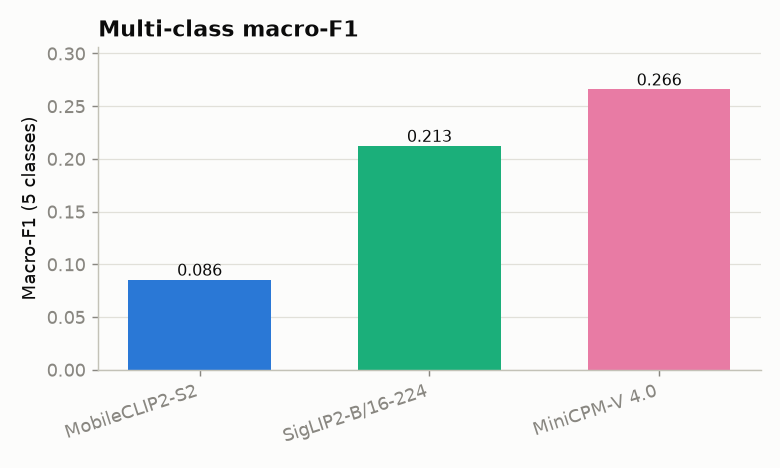

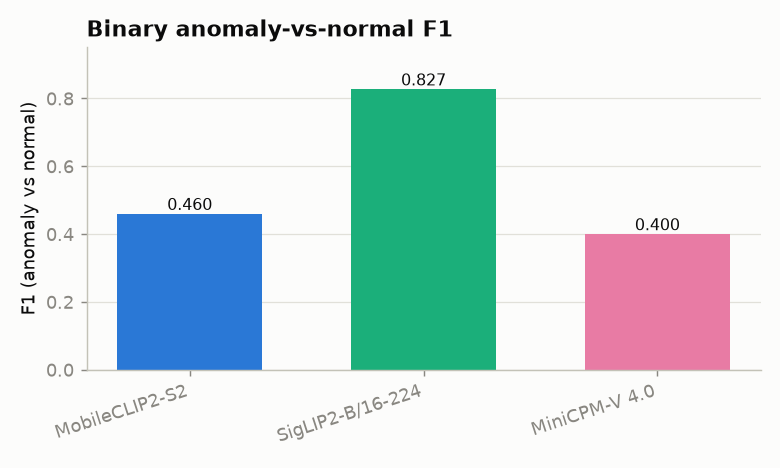

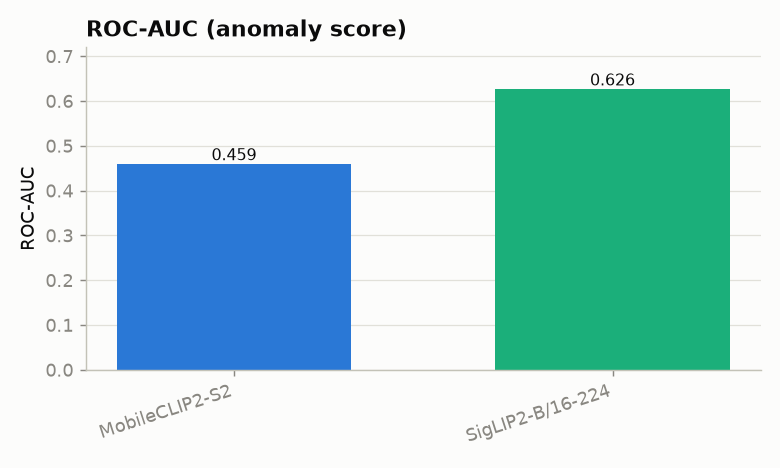

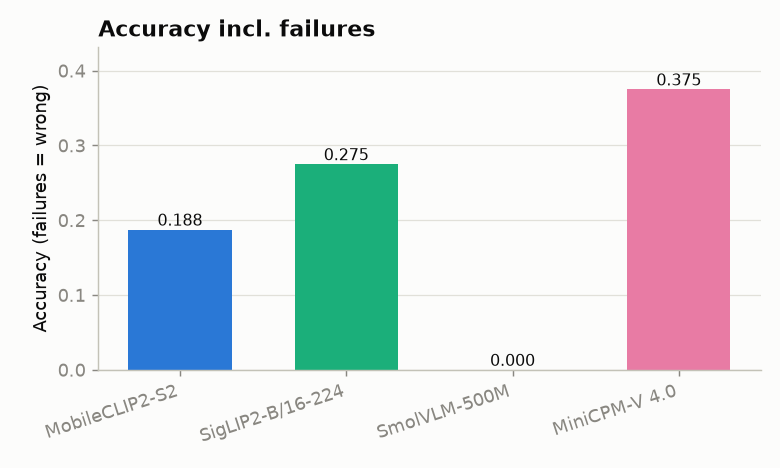

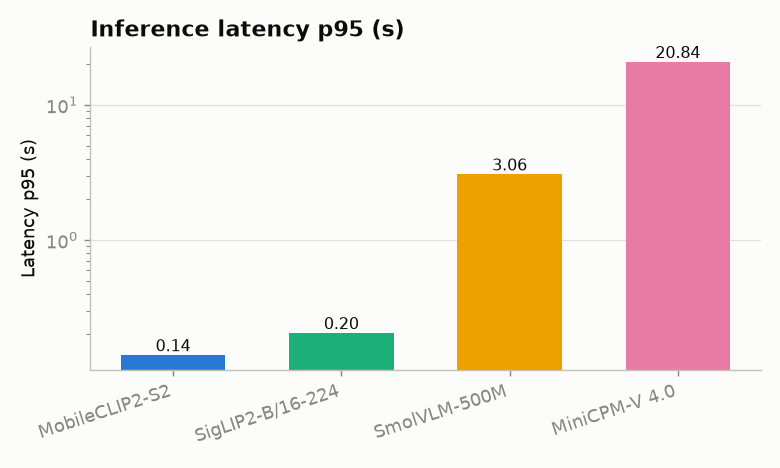

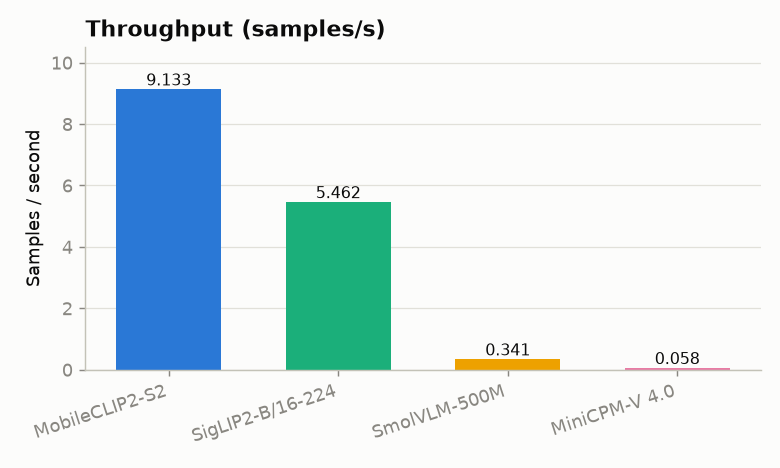

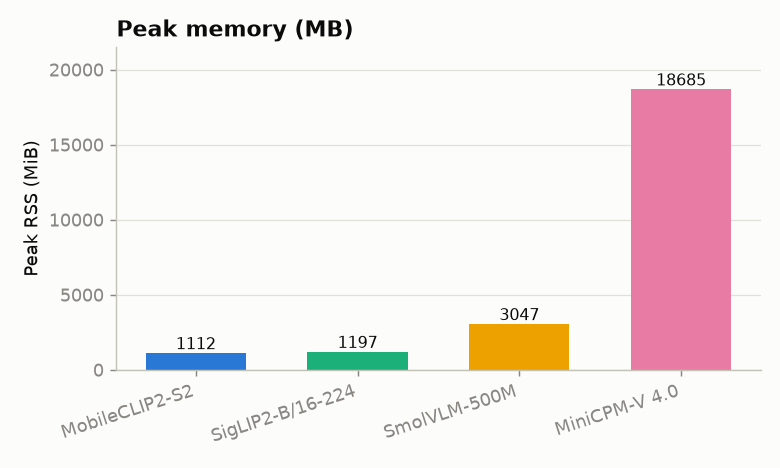

In [7]:

# ---- Show the charts --------------------------------------------------------
from IPython.display import Image, display
for p in charts:
    if Path(p).is_file():
        display(Image(filename=str(p)))



## Per-anomaly breakdown

Each anomaly is re-scored as a **binary** problem by slicing the raw predictions: for class *C*, positive = frames labelled *C*, negative = every other frame. Precision/recall/F1 use each model's predicted label (an abstention counts as "not C", i.e. a miss). ROC-AUC uses the model's numeric score for *C* — available only to the CLIP-family models, which emit per-class scores; the VLMs emit no numeric score, so their AUC is undefined here.



### smoking
model                 P      R      F1    AUC
MobileCLIP2-S2    0.100  0.062   0.077  0.519
SigLIP2-B/16-224    n/a  0.000     n/a  0.283
SmolVLM-500M        n/a  0.000     n/a    n/a
MiniCPM-V 4.0       n/a  0.000     n/a    n/a

### littering
model                 P      R      F1    AUC
MobileCLIP2-S2      n/a  0.000     n/a  0.571
SigLIP2-B/16-224  1.000  0.250   0.400  0.914
SmolVLM-500M        n/a  0.000     n/a    n/a
MiniCPM-V 4.0     1.000  0.188   0.316    n/a

### rough_sleeping
model                 P      R      F1    AUC
MobileCLIP2-S2    0.111  0.062   0.080  0.494
SigLIP2-B/16-224  0.379  0.688   0.489  0.971
SmolVLM-500M        n/a  0.000     n/a    n/a
MiniCPM-V 4.0     1.000  0.625   0.769    n/a

### loitering
model                 P      R      F1    AUC
MobileCLIP2-S2    0.000  0.000     n/a  0.252
SigLIP2-B/16-224  0.192  0.312   0.238  0.359
SmolVLM-500M        n/a  0.000     n/a    n/a
MiniCPM-V 4.0     0.500  0.062   0.111    n/a


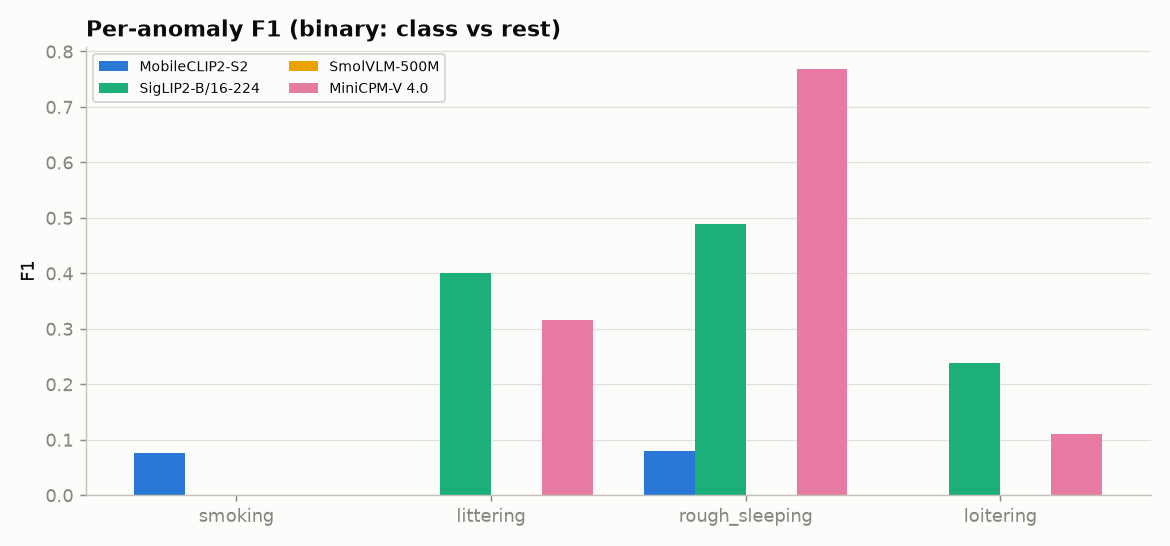

In [8]:

# ---- Per-anomaly binary metrics ---------------------------------------------
from scripts.metrics import roc_auc
import numpy as np

ANOMALIES = ["smoking", "littering", "rough_sleeping", "loitering"]

def load_predictions(model: str):
    p = RESULTS / model / "predictions.jsonl"
    if not p.is_file():
        return []
    with p.open(encoding="utf-8") as h:
        return [json.loads(line) for line in h if line.strip()]

preds = {m: load_predictions(m) for m in MODELS}

def binary_prf(rows, cls):
    tp = fp = fn = tn = 0
    for r in rows:
        pos = (r["label"] == cls)
        pred_pos = (r.get("prediction") == cls)   # abstention -> None -> not positive
        if pos and pred_pos: tp += 1
        elif (not pos) and pred_pos: fp += 1
        elif pos and (not pred_pos): fn += 1
        else: tn += 1
    precision = tp/(tp+fp) if tp+fp else None
    recall = tp/(tp+fn) if tp+fn else None
    f1 = 2*precision*recall/(precision+recall) if (precision and recall) else None
    return {"tp":tp,"fp":fp,"fn":fn,"tn":tn,"precision":precision,"recall":recall,"f1":f1}

def binary_auc(rows, cls):
    pairs = [(r["label"] == cls, r["scores"][cls]) for r in rows
             if isinstance(r.get("scores"), dict) and r.get("scores", {}).get(cls) is not None]
    return roc_auc(pairs) if len(pairs) else None

per_anom = {}
for cls in ANOMALIES:
    per_anom[cls] = {m: {**binary_prf(preds[m], cls), "auc": binary_auc(preds[m], cls)} for m in MODELS}

for cls in ANOMALIES:
    print(f"\n### {cls}")
    print(f"{'model':16} {'P':>6} {'R':>6} {'F1':>7} {'AUC':>6}")
    for m in MODELS:
        d = per_anom[cls][m]
        print(f"{MODEL_LABELS[m]:16} {_fmt(d['precision']):>6} {_fmt(d['recall']):>6} "
              f"{_fmt(d['f1']):>7} {_fmt(d['auc']):>6}")

fig, ax = plt.subplots(figsize=(9, 4.2))
x = np.arange(len(ANOMALIES)); width = 0.8/len(MODELS)
for i, m in enumerate(MODELS):
    # A model that abstained everywhere has no detections -> plot F1 as 0 (the table above shows n/a).
    vals = [(per_anom[c][m]["f1"] if per_anom[c][m]["f1"] is not None else 0.0) for c in ANOMALIES]
    ax.bar(x + (i - (len(MODELS)-1)/2)*width, vals, width=width,
           label=MODEL_LABELS[m], color=MODEL_COLORS[m])
ax.set_xticks(x); ax.set_xticklabels(ANOMALIES)
ax.set_ylabel("F1"); ax.set_title("Per-anomaly F1 (binary: class vs rest)", loc="left", fontweight="bold")
ax.grid(axis="y", color=GRID, linewidth=0.7); ax.set_axisbelow(True)
for spine in ("top","right"): ax.spines[spine].set_visible(False)
ax.legend(fontsize=8, ncol=2)
fig.tight_layout(); fig.savefig(FIGDIR/"per_anomaly_f1.png", dpi=130); plt.close(fig)
display(Image(filename=str(FIGDIR/"per_anomaly_f1.png")))



## Usability

| Model | Params (approx.) | Needs reference images? | Output type | CPU memory (fp32) | Integration effort |
|---|---|---|---|---|---|
| MobileCLIP2-S2 | ~50 M | No | softmax scores over classes (relative, not calibrated) | low (~1 GB peak here) | low — OpenCLIP + torch |
| SigLIP2-B/16-224 | ~380 M | No | independent sigmoid per-class scores (do **not** sum to 1) | moderate (~1.2 GB) | low — transformers |
| SmolVLM-500M | ~500 M | No | generated JSON label; **no numeric score** (no AUC) | moderate–high (~3 GB) | medium — generative, prompt-sensitive |
| MiniCPM-V 4.0 | ~4 B | No | generated JSON label; no numeric score | very high (~18 GB fp32 + buffers) | high — `trust_remote_code`, slow on CPU |
| VadCLIP | varies | n/a (video) | per-frame / video anomaly score | GPU strongly preferred | **high** — separate repo, weights, temporal pipeline |

### Honest caveats from this run

- **SmolVLM-500M abstained on 100% of frames.** Under the shared multi-class JSON classification prompt it returned a bare `unknown` for every image (prediction coverage = 0.0), so it has no accuracy/F1/AUC in this head-to-head. This is *over-abstention plus weak JSON adherence*, not a harness bug: with a plain "describe this image" prompt the same model produces sensible captions, and to a binary yes/no question it answers correctly. It can see the pixels but will not commit to one of the structured labels as configured. We do **not** special-case its prompt — that would be unfair tuning of a head-to-head comparison. As shipped in this harness it is unusable for this task.
- **MiniCPM-V 4.0 is far too slow for real-time CPU use.** At the shared 2-thread budget it runs at roughly ~17 s/frame and peaks near ~18 GB of RAM, so it needs a large per-model timeout to finish 80 frames at all. It is best treated as an offline second pass / reviewer, not a primary detector.

**Reading the numbers.** CLIP-style models give fast scores and are trivial to deploy on CPU — the natural first line for a real-time camera feed. VLMs can reason about *what* is happening but are far slower, produce no numeric score (no ROC-AUC), and abstain more often.


In [9]:

# ---- Data-driven fit ranking ------------------------------------------------
def _norm(vals):
    vals = [v for v in vals if v is not None]
    lo, hi = (min(vals), max(vals)) if vals else (0, 1)
    span = (hi - lo) or 1.0
    return [(v - lo)/span if v is not None else 0.0 for v in vals]

# Components (all higher-is-better). Abstaining models score 0 on the accuracy terms.
usable_acc = [(r["coverage"] or 0.0) * (r["macro_f1"] or 0.0) for r in table]   # coverage-gated accuracy
binf1      = [r["bin_f1"] if r["bin_f1"] is not None else 0.0 for r in table]
auc        = [r["roc_auc"] if r["roc_auc"] is not None else 0.0 for r in table]
thr        = [r["throughput"] or 0.0 for r in table]
mem_inv    = [(1.0/r["rss_mb"]) if (r["rss_mb"] and r["rss_mb"] > 0) else 0.0 for r in table]

n_acc, n_bin, n_auc, n_thr, n_mem = _norm(usable_acc), _norm(binf1), _norm(auc), _norm(thr), _norm(mem_inv)
W = {"acc":0.35, "bin":0.20, "auc":0.15, "thr":0.20, "mem":0.10}

ranking = []
for i, r in enumerate(table):
    score = (W["acc"]*n_acc[i] + W["bin"]*n_bin[i] + W["auc"]*n_auc[i]
             + W["thr"]*n_thr[i] + W["mem"]*n_mem[i])
    ranking.append((score, r))
ranking.sort(key=lambda t: -t[0])

print(f"{'rank':<5} {'model':16} {'fit':>6}   (acc .35 / binF1 .20 / AUC .15 / speed .20 / mem .10)")
for rank, (score, r) in enumerate(ranking, start=1):
    print(f"{rank:<5} {r['model']:16} {score:>6.3f}")


rank  model               fit   (acc .35 / binF1 .20 / AUC .15 / speed .20 / mem .10)
1     SigLIP2-B/16-224  0.841
2     MobileCLIP2-S2    0.634
3     MiniCPM-V 4.0     0.447
4     SmolVLM-500M      0.039



## Findings & recommendation

The fit ranking above blends usable accuracy (coverage-gated macro-F1), binary F1, AUC, speed and memory. The measured picture:

- **Most accurate on exact class: MiniCPM-V 4.0.** It has the highest accuracy-including-failures (~0.38) and macro-F1 (~0.27) of the four — it is genuinely better at naming *which* anomaly is present. But at ~17 s/frame and a ~18 GB peak it is impractical as a real-time CPU detector; treat it as an offline second pass / reviewer on frames already flagged by a fast model.
- **Best practical frame-level CPU detector: SigLIP2-B/16-224.** It leads on the anomaly-vs-normal split (binary F1 ~0.83, ROC-AUC ~0.63) while staying fast (~0.2 s/frame) and light (~1.2 GB). It needs no reference images and returns a usable per-class score — the recommended default for a live feed where you mainly need to know *whether* something is wrong.
- **MobileCLIP2-S2** is the fastest (sub-0.15 s/frame, lowest memory) but scores lower on this taxonomy; a good lightweight option when latency dominates over accuracy.
- **SmolVLM-500M** abstained on every frame under the structured prompt and therefore has no usable score here — see the usability caveats. It is not recommended as configured for this task.
- **VadCLIP** targets the *temporal* anomalies (loitering, unattended items) that no single still can confirm; it belongs in a separate video pipeline and is documented below rather than forced into this frame-level comparison.

> **Bottom line:** accuracy and deployability pull in different directions here. For detecting these public-space anomalies on CPU from individual frames in real time, use **SigLIP2-B/16-224** as the primary detector (fast, scored, no references), optionally with MobileCLIP2-S2 where latency is paramount; if you can afford offline batch processing and want the best exact-class accuracy, run **MiniCPM-V 4.0** as a second pass on flagged frames; and reserve a video model for temporal cases.



## VadCLIP — documented, not run in this head-to-head

VadCLIP (and the UCF-Crime / XD-Violence detectors in its family) is a **temporal video** anomaly detector: it scores *frame sequences* against a fixed set of crime/violence classes using an upstream 3D-conv / optical-flow feature pipeline. Two things keep it out of this single-frame CPU comparison:

1. **Modality.** It consumes a clip and emits one score per video; our manifest is image-level, so there is no temporal input to feed it. Loitering and unattended items are inherently temporal — a single still cannot confirm them.
2. **Taxonomy.** Its labels (e.g. `abuse`, `arson`, `road_accidents`) do not include this project's anomalies (smoking, littering, rough sleeping, loitering, unattended items), so even a valid run would have no ground-truth class to score against.

A documentation-only stub — `VadCLIPAdapter` in `scripts/models.py` — marks where it would plug in and is deliberately **not** registered in `MODELS`, so `benchmark.py --list-models` never offers it. The cell below proves that programmatically. To add real support later: vendor the upstream repo + a UCF-Crime/XD-Violence checkpoint, build a clip sampler grouping consecutive frames by `group_id`, map its score onto `Prediction.anomaly_score` (treating "any crime" as positive), and run it through its own video pipeline (`scripts/vadclip.py`) rather than this harness.


In [10]:

# ---- Prove the VadCLIP stub is present but not runnable ---------------------
import scripts.models as M

print("VadCLIPAdapter defined      :", hasattr(M, "VadCLIPAdapter"))
print("registered in MODELS        :", any("vadclip" in k.lower() for k in M.MODELS))
try:
    M.VadCLIPAdapter(M.ModelSpec(kind="video", checkpoint="x"), {}, {})
except NotImplementedError:
    print("constructor raises          : NotImplementedError (documentation-only stub)")
print("\nfirst line of the stub's docstring:")
print((M.VadCLIPAdapter.__doc__ or "").strip().splitlines()[0])


VadCLIPAdapter defined      : True
registered in MODELS        : False
constructor raises          : NotImplementedError (documentation-only stub)

first line of the stub's docstring:
Documented stub for a temporal video anomaly detector -- NOT runnable here.



## Reproduction

Everything above is reproducible from the repo root:

```bash
# 1) build the balanced manifest (deterministic, seed 42)
python -I scripts/derive_labels.py --out data/anomaly_manifest.csv --per-class 16 --seed 42

# 2) run the head-to-head benchmark (all four models, same 80 frames)
python -I scripts/benchmark.py \
    --manifest data/anomaly_manifest.csv \
    --models mobileclip2-s2 siglip2-b16-224 smolvlm-500m minicpm-v4 \
    --limit 80 --seed 42 --threads 2 --duty-cycle 1 \
    --timeout-seconds 3600 --offline \
    --output results/anomaly_headtohead

# 3) unit tests for label derivation
python -m unittest discover -s tests
```

Results live in `results/anomaly_headtohead/` (`comparison.csv`, per-model `summary.json` and `predictions.jsonl`). Charts are written to `notebooks/anomaly_benchmark_figures/`.
